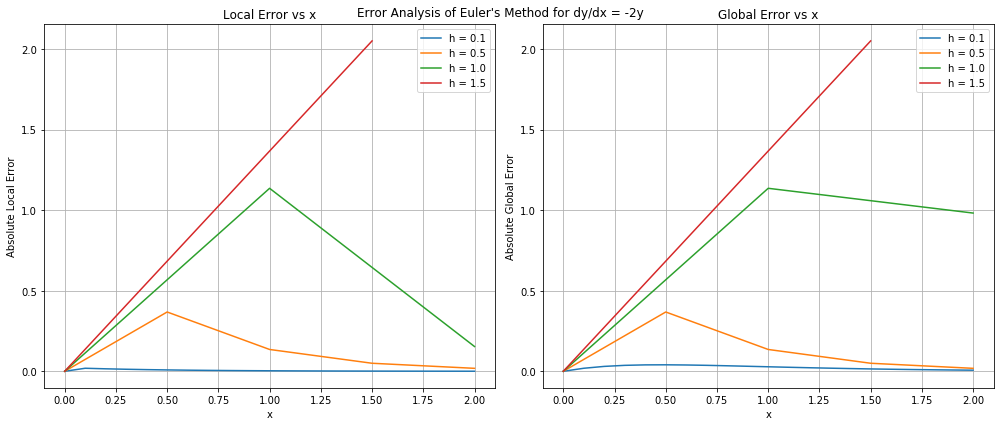

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return -2 * y

def exact_solution(x):
    return np.exp(-2 * x)

def calculate_errors(h, x_start=0, x_end=2):
    x_values = np.arange(x_start, x_end + 1e-9, h)
    num_steps = len(x_values) - 1
    
    y_approx = np.zeros(num_steps + 1)
    y_exact = np.zeros(num_steps + 1)
    local_error = np.zeros(num_steps + 1)
    global_error = np.zeros(num_steps + 1)
    
    y_approx[0] = 1
    y_exact[0] = exact_solution(x_values[0])
    
    for i in range(num_steps):
        xi = x_values[i]
        yi = y_approx[i]
        
        y_approx[i + 1] = yi + h * f(xi, yi)
        y_exact[i + 1] = exact_solution(x_values[i + 1])
        
        exact_prev = exact_solution(xi)
        euler_from_exact = exact_prev + h * f(xi, exact_prev)
        local_error[i + 1] = np.abs(y_exact[i + 1] - euler_from_exact)
        
        global_error[i + 1] = np.abs(y_exact[i + 1] - y_approx[i + 1])
        
    return x_values, y_approx, y_exact, local_error, global_error

h_values = [0.1, 0.5, 1.0, 1.5]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for h in h_values:
    x_vals, y_app, y_ex, loc_err, glob_err = calculate_errors(h, x_start=0, x_end=2)
    
    ax1.plot(x_vals, loc_err, label=f'h = {h}')
    ax2.plot(x_vals, glob_err, label=f'h = {h}')

ax1.set_title("Local Error vs x")
ax1.set_xlabel("x")
ax1.set_ylabel("Absolute Local Error")
ax1.grid(True)
ax1.legend()

ax2.set_title("Global Error vs x")
ax2.set_xlabel("x")
ax2.set_ylabel("Absolute Global Error")
ax2.grid(True)
ax2.legend()

plt.suptitle("Error Analysis of Euler's Method for dy/dx = -2y")
plt.tight_layout()
plt.show()